In [179]:
%pip install pandas numpy statsmodels scikit-learn matplotlib

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


In [180]:
combine = pd.read_csv("2025 Combine Results.csv")
combine.columns = combine.columns.str.strip()

rankings = pd.read_csv("2025 Player Rankings.csv", encoding="latin1")
rankings.columns = rankings.columns.str.strip()

print(combine.shape)
print(rankings.shape)

(329, 15)
(4597, 23)


In [181]:
def clean_name(name):
    name = str(name).lower()
    name = name.replace(".", "").replace(",", "")
    name = name.replace(" jr", "").replace(" sr", "")
    name = name.replace(" iii", "").replace(" ii", "")
    return name.strip()

combine["player_clean"] = combine["Player"].apply(clean_name)
rankings["Name_clean"] = rankings["Name"].apply(clean_name)

In [182]:
combine = combine.merge(
    rankings[["Name_clean", "AveragePPA All"]],
    left_on="player_clean",
    right_on="Name_clean",
    how="left"
)

print(combine[["Player", "AveragePPA All"]].head(10))
print("Players with PPA matched:", combine["AveragePPA All"].notna().sum())

              Player  AveragePPA All
0           BJ Adams             NaN
1  Tommy Akingbesote             NaN
2   Darius Alexander             NaN
3       Zy Alexander             NaN
4      LeQuint Allen             NaN
5          Trey Amos             NaN
6   Andrew Armstrong             NaN
7      Elijah Arroyo             NaN
8      Eugene Asante             NaN
9      Elic Ayomanor             NaN
Players with PPA matched: 3


In [183]:
combine["Pick"] = combine["Drafted (tm/rnd/yr)"].str.extract(
    r'(\d+)(?=th pick|st pick|nd pick|rd pick)'
).astype(float)

print("Drafted players:", combine["Pick"].notna().sum())

Drafted players: 215


In [184]:
df = combine.dropna(subset=["Pick"]).copy()
print(df.shape)

(215, 19)


In [185]:
features = [
    "40yd", "Vertical", "Bench", "Broad Jump",
    "3Cone", "Shuttle", "Ht", "Wt", "AveragePPA All", "Pos"
]

model_df = df[["Pick"] + features].copy()

In [186]:
num_cols = ["40yd", "Vertical", "Bench", "Broad Jump", "3Cone", "Shuttle", "Ht", "Wt", "AveragePPA All"]

for col in num_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

In [187]:
for col in num_cols:
    model_df[col + "_missing"] = model_df[col].isna().astype(int)

In [188]:
model_df[num_cols] = model_df.groupby("Pos")[num_cols].transform(
    lambda x: x.fillna(x.mean())
)

model_df[num_cols] = model_df[num_cols].fillna(model_df[num_cols].mean())

In [189]:
model_df = pd.get_dummies(model_df, columns=["Pos"], drop_first=True)

In [190]:
model_df = model_df.drop(columns=["Broad Jump", "3Cone", "Shuttle"], errors="ignore")

In [191]:
model_df["log_pick"] = np.log(model_df["Pick"])

In [192]:
X = model_df.drop(columns=["Pick", "log_pick"])
y = model_df["log_pick"]

X = X.astype(float)
X = sm.add_constant(X)

In [193]:
# Drop rows with ANY missing values for VIF calculation only
X_vif = X.dropna().copy()

In [194]:
# Keep only strong, interpretable variables
core_cols = ["40yd", "Wt", "Vertical", "Bench", "AveragePPA All"]

pos_cols = [col for col in model_df.columns if col.startswith("Pos_")]
pos_cols = pos_cols[:8]

X_small = model_df[core_cols + pos_cols].copy()

In [195]:
X_small = X_small.replace([np.inf, -np.inf], np.nan).dropna()
X_small = X_small.loc[:, X_small.std() != 0]
X_small = X_small.astype(float)

In [196]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X_small.columns
vif_data["VIF"] = [variance_inflation_factor(X_small.values, i) for i in range(X_small.shape[1])]

print(vif_data.sort_values("VIF", ascending=False))

           feature         VIF
0             40yd  604.207819
1               Wt  264.989568
2         Vertical  153.598283
3            Bench  134.964829
4   AveragePPA All   61.886234
7           Pos_DT    4.325492
12          Pos_OT    3.407997
8         Pos_EDGE    2.662560
9            Pos_G    2.290842
11          Pos_LB    1.826494
5           Pos_CB    1.353686
6        Pos_CB/WR    1.048632
10           Pos_K    1.033333


In [197]:
X_small = model_df[["40yd", "Vertical", "AveragePPA All"] + [col for col in model_df.columns if "Pos_" in col]]

In [198]:
X_small = X_small.astype(float)
X_small = sm.add_constant(X_small)

model = sm.OLS(y, X_small).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_pick   R-squared:                       0.187
Model:                            OLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     2.665
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           0.000608
Time:                        02:54:37   Log-Likelihood:                -279.06
No. Observations:                 215   AIC:                             594.1
Df Residuals:                     197   BIC:                             654.8
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -7.9631      4.951     -1.

In [199]:
model_df["predicted_pick"] = np.exp(model.fittedvalues)

In [200]:
model_df["percentile"] = pd.qcut(model_df["Pick"], 10, labels=False)

In [201]:
def assign_group(p):
    if p == 0:
        return "Top 10%"
    elif p == 1:
        return "Next 10%"
    elif p == 2:
        return "Next 10% After That"
    else:
        return "Remaining 70%"

model_df["group"] = model_df["percentile"].apply(assign_group)

In [202]:
group_summary = model_df.groupby("group").apply(
    lambda x: pd.Series({
        "Count": len(x),
        "Avg Actual Pick": x["Pick"].mean(),
        "Avg Predicted Pick": x["predicted_pick"].mean(),
        "MAE": abs(x["Pick"] - x["predicted_pick"]).mean(),
        "MAPE (%)": (abs(x["Pick"] - x["predicted_pick"]) / x["Pick"]).mean() * 100,
        "RMSE": np.sqrt(((x["Pick"] - x["predicted_pick"])**2).mean())
    })
).reset_index()

In [203]:
order = ["Top 10%", "Next 10%", "Next 10% After That", "Remaining 70%"]

group_summary["group"] = pd.Categorical(
    group_summary["group"],
    categories=order,
    ordered=True
)

group_summary = group_summary.sort_values("group")

print(group_summary)

                 group  Count  Avg Actual Pick  Avg Predicted Pick        MAE  \
3              Top 10%   22.0        11.727273           73.918312  62.191039   
0             Next 10%   21.0        34.000000           76.789644  42.789644   
1  Next 10% After That   22.0        55.500000           79.146352  24.898980   
2        Remaining 70%  150.0       151.706667           96.404199  62.876988   

     MAPE (%)       RMSE  
3  972.432059  71.950076  
0  134.161018  47.412063  
1   46.211451  30.633788  
2   37.087614  78.918772  


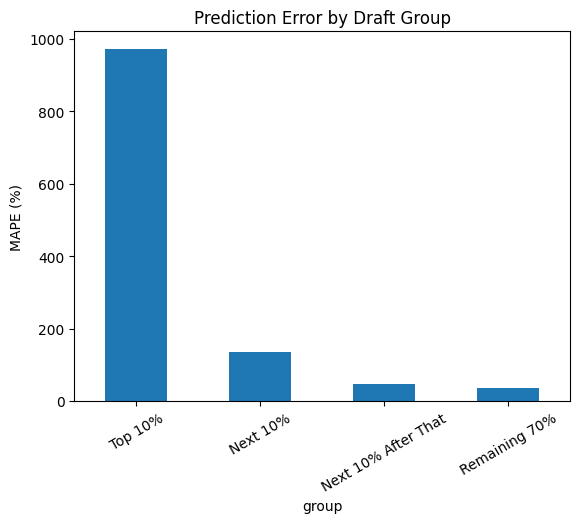

In [204]:
group_summary.plot(
    x="group",
    y="MAPE (%)",
    kind="bar",
    legend=False
)

plt.title("Prediction Error by Draft Group")
plt.ylabel("MAPE (%)")
plt.xticks(rotation=30)
plt.show()